In [ ]:
#Responsible Machine Learning
#Student ID: G22169515

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
#First step, loading the dataset and inspect the first rows
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

print("Number of rows in raw data:", raw_data.shape[0])
print("\nFirst 10 rows:")
print(raw_data.head(10))


Number of rows in raw data: 7214

First 10 rows:
   id                name      first         last compas_screening_date  \
0   1    miguel hernandez     miguel    hernandez            2013-08-14   
1   3         kevon dixon      kevon        dixon            2013-01-27   
2   4            ed philo         ed        philo            2013-04-14   
3   5         marcu brown      marcu        brown            2013-01-13   
4   6  bouthy pierrelouis     bouthy  pierrelouis            2013-03-26   
5   7        marsha miles     marsha        miles            2013-11-30   
6   8       edward riddle     edward       riddle            2014-02-19   
7   9      steven stewart     steven      stewart            2013-08-30   
8  10    elizabeth thieme  elizabeth       thieme            2014-03-16   
9  13           bo bradac         bo       bradac            2013-11-04   

      sex         dob  age          age_cat              race  ...  \
0    Male  1947-04-18   69  Greater than 45            

In [ ]:
#Define numeric and datetime columns, then keep the variables used in the analysis
#filtering only the necessary data
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
    "priors_count", "days_b_screening_arrest", "decile_score",
    "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"
]].copy()

# Filters
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

print("Number of rows after filtering:", df.shape[0])

Number of rows after filtering: 6172


In [ ]:
#Type conversions
#For dates
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", errors="coerce", utc=True)

#Convert non-numeric and non-datetime columns to categorical type
for col in df.columns:
    if col not in numeric_vars + datetime_vars:
        df[col] = df[col].astype("category")

In [ ]:
#Derived factor variables used in the regression model
df["crime_factor"] = df["c_charge_degree"].astype("category")

#Reference groups
df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["Less than 25", "25 - 45", "Greater than 45"]
)

race_levels = ["Caucasian"] + [x for x in df["race"].unique() if x != "Caucasian"]
df["race_factor"] = pd.Categorical(df["race"], categories=race_levels)

df["gender_factor"] = pd.Categorical(df["sex"], categories=["Male", "Female"])

df["score_factor"] = np.where(df["score_text"] == "Low", "LowScore", "HighScore")
df["score_factor"] = pd.Categorical(df["score_factor"], categories=["LowScore", "HighScore"])

print(df.shape[0])

6172


In [ ]:
#Higher COMPAS scores are slightly correlated with a longer length of stay (using jail in and jail out dates)
df["length_of_stay"] = (
    df["c_jail_out"].dt.normalize() - df["c_jail_in"].dt.normalize()
).dt.days

correlation = df["length_of_stay"].corr(df["decile_score"])
print(correlation)

0.2073296916147045


In [ ]:
#First summary by age category
print("After filtering we have the following demographic breakdown:")
print("Age category summary")
print(df["age_cat"].value_counts(dropna=False).sort_index())


After filtering we have the following demographic breakdown:
Age category summary
age_cat
25 - 45            3532
Greater than 45    1293
Less than 25       1347
Name: count, dtype: int64


In [ ]:
#Summary of values by race
print("Race summary")
print(df["race"].value_counts(dropna=False))


Race summary
race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


In [ ]:
#% reported are the same as on the R script
print("Black defendants:", 3175 / 6172 * 100, "%")
print("White defendants:", 2103 / 6172 * 100, "%")
print("Hispanic defendants:", 509 / 6172 * 100, "%")
print("Asian defendants:", 31 / 6172 * 100, "%")
print("Native American defendants:", 11 / 6172 * 100, "%")

Black defendants: 51.441996111471155 %
White defendants: 34.07323395981853 %
Hispanic defendants: 8.246921581335062 %
Asian defendants: 0.5022683084899546 %
Native American defendants: 0.1782242384964355 %


In [ ]:
#Summary by score, sex by race, sex
print("Score text summary")
print(df["score_text"].value_counts(dropna=False))

Score text summary
score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [ ]:
print("Sex by race table")
print(pd.crosstab(df["sex"], df["race"]))

Sex by race table
race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [ ]:
print("Sex summary")
print(df["sex"].value_counts(dropna=False))

print("Men:", 4997 / 6172 * 100, "%")
print("Women:", 1175 / 6172 * 100, "%")

Sex summary
sex
Male      4997
Female    1175
Name: count, dtype: int64
Men: 80.96241088788075 %
Women: 19.03758911211925 %


In [ ]:
#Quantity of defendants within two years
recid_count = (df["two_year_recid"] == 1).sum()
recid_pct = recid_count / len(df) * 100

print(recid_count)
print(recid_pct)

2809
45.51198963058976


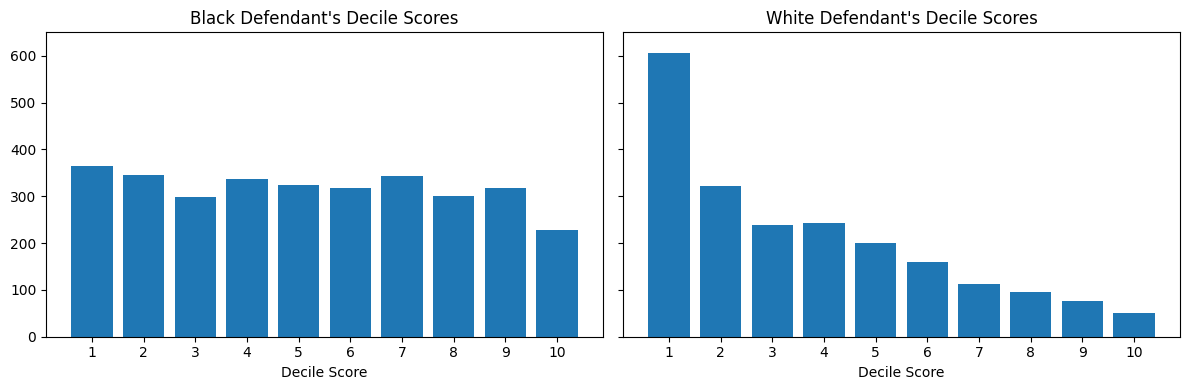

In [ ]:
#Comparative graphs of scores of black defendants and white defendants
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

black_df = df[df["race"] == "African-American"]
white_df = df[df["race"] == "Caucasian"]

black_counts = black_df["decile_score"].value_counts().sort_index()
white_counts = white_df["decile_score"].value_counts().sort_index()

axes[0].bar(black_counts.index.astype(str), black_counts.values)
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylim(0, 650)

axes[1].bar(white_counts.index.astype(str), white_counts.values)
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()


In [ ]:
#Cross tabs of decils x race
print("Cross-tab of decile_score by race:")
print(pd.crosstab(df["decile_score"], df["race"]))

Cross-tab of decile_score by race:
race          African-American  Asian  Caucasian  Hispanic  Native American  \
decile_score                                                                  
1                          365     15        605       159                0   
2                          346      4        321        89                2   
3                          298      5        238        73                1   
4                          337      0        243        47                0   
5                          323      1        200        39                0   
6                          318      2        160        27                2   
7                          343      1        113        28                2   
8                          301      2         96        14                0   
9                          317      0         77        17                2   
10                         227      1         50        16                2   

race          Ot

In [ ]:
#Using score factor as a numeric for the model
df["score_factor_num"] = np.where(df["score_factor"] == "HighScore", 1, 0)

#Creation of the model
model_glm = smf.glm(
    formula="""
    score_factor_num ~ C(gender_factor, Treatment(reference='Male'))
                     + C(age_factor, Treatment(reference='25 - 45'))
                     + C(race_factor, Treatment(reference='Caucasian'))
                     + priors_count
                     + C(crime_factor)
                     + two_year_recid
    """,
    data=df,
    family=sm.families.Binomial()
).fit()

print("Logistic regression summary:")
print(model_glm.summary())

Logistic regression summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:       score_factor_num   No. Observations:                 6172
Model:                            GLM   Df Residuals:                     6160
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3084.2
Date:                Fri, 27 Mar 2026   Deviance:                       6168.4
Time:                        19:59:08   Pearson chi2:                 6.07e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3128
Covariance Type:            nonrobust                                         
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------

In [ ]:
#Using the coefficient values reported, we get the same values as the R script
control = np.exp(-1.52554) / (1 + np.exp(-1.52554))

black_effect = np.exp(0.47721) / (1 - control + control * np.exp(0.47721))
female_effect = np.exp(0.22127) / (1 - control + control * np.exp(0.22127))
young_effect = np.exp(1.30839) / (1 - control + control * np.exp(1.30839))

print("Black vs White transformed effect:", black_effect)
print("Female vs Male transformed effect:", female_effect)
print("Under 25 vs 25-45 transformed effect:", young_effect)

Black vs White transformed effect: 1.4528408658138932
Female vs Male transformed effect: 1.1947978508506671
Under 25 vs 25-45 transformed effect: 2.4961202077189455


In [ ]:
#Obtaining the probability of each value calculated, assigning if its recid or no recid
df["pred_prob"] = model_glm.predict(df)
df["pred_class"] = np.where(df["pred_prob"] >= 0.5, "Recid", "No Recid")


In [ ]:
#The general confusion matrix is generated to evalute in a high level the confidence of the model
print("Overall Confusion Matrix")
overall_cm = pd.crosstab(
    df["pred_class"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)
print(overall_cm)

#Calculating the true positives, true negatives, etc for the next step
TP = overall_cm.loc["Recid", 1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid", 0]
FN = overall_cm.loc["No Recid", 1]
n = overall_cm.to_numpy().sum()

#Each of this variables help us to understand how correctly the model got the results vs the training data
accuracy = (TP + TN) / n
precision = TP / (TP + FP)
recall = TP / (TP + FN)
fpr = FP / (FP + TN)
fnr = FN / (FN + TP)

print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("FPR      :", round(fpr, 3))
print("FNR      :", round(fnr, 3))

Overall Confusion Matrix
Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864
Accuracy : 0.732
Precision: 0.724
Recall   : 0.664
FPR      : 0.211
FNR      : 0.336


In [ ]:
#We start to deep dive on the confusion matrix first by race
print("Confusion Matrix by Race")

df["actual"] = df["two_year_recid"].astype(int)
df["pred"] = (df["pred_class"] == "Recid").astype(int)

race_metrics = []

#Considering we have more than 1 race, For command is necessary
for race_name, group in df.groupby("race"):
    TP_r = ((group["pred"] == 1) & (group["actual"] == 1)).sum()
    TN_r = ((group["pred"] == 0) & (group["actual"] == 0)).sum()
    FP_r = ((group["pred"] == 1) & (group["actual"] == 0)).sum()
    FN_r = ((group["pred"] == 0) & (group["actual"] == 1)).sum()
    n_r = len(group)
#Table is generated
    race_metrics.append({
        "race": race_name,
        "n": n_r,
        "TP": TP_r,
        "TN": TN_r,
        "FP": FP_r,
        "FN": FN_r,
        "Accuracy": round((TP_r + TN_r) / n_r, 3),
        "Precision": round(TP_r / (TP_r + FP_r), 3),
        "Recall": round(TP_r / (TP_r + FN_r), 3),
        "FPR": round(FP_r / (FP_r + TN_r), 3),
        "FNR": round(FN_r / (FN_r + TP_r), 3)
    })

race_metrics = pd.DataFrame(race_metrics).sort_values("n", ascending=False)
print(race_metrics)

Confusion Matrix by Race
               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


/tmp/ipykernel_646/803307287.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for race_name, group in df.groupby("race"):


In [ ]:
#Obtaining the rates of false positives and false negatives by race
print("FPR and FNR Disparity by Race")

#Considering caucassian as a reference for race, we obtain the difference of each race FP and FN values vs the caucassian
disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()
caucasian_fpr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FPR"].iloc[0]
caucasian_fnr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FNR"].iloc[0]

disparity["delta_FPR"] = (disparity["FPR"] - caucasian_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - caucasian_fnr).round(3)

print(disparity)

FPR and FNR Disparity by Race
               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536


# Interpretation
The length of stay and decile score shows a positive correlation. The logistic regression help us to estimate if a defendant receives a HighScore vs LowScore, the coefficients used for race, age, and gender can be interpreted relative to their reference groups declared on the code.

The confusion matrix shows us how often a prediction of a high-risk classifications align with actual two-year recidivism outcomes.
Thats super important if wee see it together with FPR and FNR, because they measure how often non-recidivists are incorrectly classified as Recid and how often actual recidivists are missed respectively.

To close the idea, the final tables shows if some groups experience higher false positive or false negative rates compared with Caucasian defendants.